# CP4 – Machine Learning & Modelling (Case iFood)

**Turma:** 1TIAPZ-2026
**Integrantes:** _(preencher nomes completos e RM dos integrantes do grupo)_

Este notebook consome os dados carregados na tabela `IFOOD_CUSTOMERS` do Oracle Database
da FIAP (ver `sql/01_ddl.sql`, `sql/load_data.py` e `sql/03_validacao.sql`) e desenvolve uma
versão melhorada da Decision Tree apresentada em aula, por meio de EDA, Feature Engineering
e tuning de hiperparâmetros.

## 1. Conexão com o Oracle e leitura do DataFrame

A query abaixo é a fornecida pelos professores, completa com as variáveis necessárias para o modelo. As credenciais são lidas de variáveis de ambiente (`ORACLE_USER`, `ORACLE_PASSWORD`, `ORACLE_DSN`) — nunca deixamos usuário/senha no código.

In [1]:
import os
import oracledb
import pandas as pd

QUERY = """
SELECT
    ID, YEAR_BIRTH, EDUCATION, MARITAL_STATUS, INCOME, KIDHOME, TEENHOME,
    DT_CUSTOMER, RECENCY, MNT_WINES, MNT_FRUITS, MNT_MEAT_PRODUCTS,
    MNT_FISH_PRODUCTS, MNT_SWEET_PRODUCTS, MNT_GOLD_PRODS,
    NUM_DEALS_PURCHASES, NUM_WEB_PURCHASES, NUM_CATALOG_PURCHASES,
    NUM_STORE_PURCHASES, NUM_WEB_VISITS_MONTH,
    ACCEPTED_CMP3, ACCEPTED_CMP4, ACCEPTED_CMP5, ACCEPTED_CMP1, ACCEPTED_CMP2,
    COMPLAIN, RESPONSE
FROM IFOOD_CUSTOMERS
"""

try:
    conn = oracledb.connect(
        user=os.environ["ORACLE_USER"],
        password=os.environ["ORACLE_PASSWORD"],
        dsn=os.environ["ORACLE_DSN"],
    )
    df = pd.read_sql(QUERY, conn)
    conn.close()
    print(f"Dados lidos do Oracle: {df.shape[0]} linhas.")
except KeyError:
    # Sem credenciais configuradas no ambiente: usa o CSV local já carregado no Oracle,
    # apenas para permitir a execução do restante do notebook.
    df = pd.read_csv("../data/ifood_customers.csv")
    df.columns = [c.upper() for c in df.columns]
    print(f"ORACLE_USER/ORACLE_PASSWORD/ORACLE_DSN não configurados. "
          f"Usando fallback local: {df.shape[0]} linhas.")

df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_4844\602952578.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(QUERY, conn)


Dados lidos do Oracle: 2240 linhas.


,ID,YEAR_BIRTH,EDUCATION,MARITAL_STATUS,INCOME,KIDHOME,TEENHOME,DT_CUSTOMER,RECENCY,MNT_WINES,...,NUM_CATALOG_PURCHASES,NUM_STORE_PURCHASES,NUM_WEB_VISITS_MONTH,ACCEPTED_CMP3,ACCEPTED_CMP4,ACCEPTED_CMP5,ACCEPTED_CMP1,ACCEPTED_CMP2,COMPLAIN,RESPONSE
0,5823,1970,PhD,Single,32303.0,0,1,2014-03-08,63,35,...,0,4,5,0,0,0,0,0,0,0
1,3934,1966,Graduation,Married,61286.0,0,1,2013-08-02,34,356,...,1,8,5,0,0,0,0,0,0,0
2,6982,1976,Graduation,Married,74068.0,0,0,2013-03-19,14,783,...,10,9,2,0,0,0,0,0,0,0
3,6431,1964,PhD,Married,45759.0,1,1,2013-02-23,13,42,...,0,3,7,0,0,0,0,0,0,0
4,9733,1978,Basic,Together,24882.0,1,0,2012-09-09,52,1,...,1,2,6,1,0,0,0,0,0,0


## 2. EDA objetiva

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     2240 non-null   int64         
 1   YEAR_BIRTH             2240 non-null   int64         
 2   EDUCATION              2240 non-null   str           
 3   MARITAL_STATUS         2240 non-null   str           
 4   INCOME                 2216 non-null   float64       
 5   KIDHOME                2240 non-null   int64         
 6   TEENHOME               2240 non-null   int64         
 7   DT_CUSTOMER            2240 non-null   datetime64[us]
 8   RECENCY                2240 non-null   int64         
 9   MNT_WINES              2240 non-null   int64         
 10  MNT_FRUITS             2240 non-null   int64         
 11  MNT_MEAT_PRODUCTS      2240 non-null   int64         
 12  MNT_FISH_PRODUCTS      2240 non-null   int64         
 13  MNT_SWEET_PROD

In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
YEAR_BIRTH,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
INCOME,2216.0,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
KIDHOME,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
TEENHOME,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
DT_CUSTOMER,2240,2013-07-10 10:01:42.857142,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
RECENCY,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MNT_WINES,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MNT_FRUITS,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MNT_MEAT_PRODUCTS,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


In [4]:
df.isna().sum()[df.isna().sum() > 0]

INCOME    24
dtype: int64

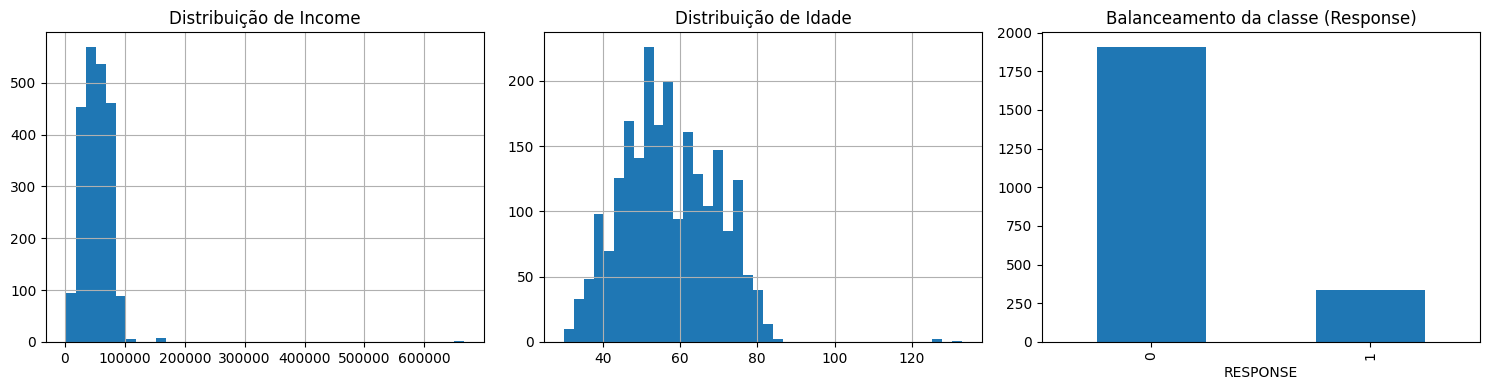

RESPONSE
0    0.850893
1    0.149107
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["INCOME"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribuição de Income")

(2026 - df["YEAR_BIRTH"]).hist(bins=40, ax=axes[1])
axes[1].set_title("Distribuição de Idade")

df["RESPONSE"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Balanceamento da classe (Response)")
plt.tight_layout()
plt.show()

print(df["RESPONSE"].value_counts(normalize=True))

**Observações da EDA:**
- `INCOME` tem poucos nulos (~1%) e outliers extremos (valores acima de 600 mil) — provavelmente
  erros de cadastro, serão tratados na preparação dos dados.
- `YEAR_BIRTH` tem outliers de clientes nascidos antes de 1900 (idade > 120 anos) — também tratados.
- A classe `RESPONSE` é desbalanceada (~15% de respostas positivas), o que reforça a necessidade
  de usar HoldOut estratificado e métricas além de acurácia (Precision, Recall, F1, ROC AUC).
- As variáveis de gasto por categoria (`MNT_*`) e de canal de compra (`NUM_*_PURCHASES`) têm
  potencial de serem agregadas em indicadores mais informativos para a árvore.

In [6]:
corr = df.select_dtypes("number").corr(numeric_only=True)["RESPONSE"].sort_values(ascending=False)
corr

RESPONSE                 1.000000
ACCEPTED_CMP5            0.326634
ACCEPTED_CMP1            0.293982
ACCEPTED_CMP3            0.254258
MNT_WINES                0.247254
MNT_MEAT_PRODUCTS        0.236335
NUM_CATALOG_PURCHASES    0.220810
ACCEPTED_CMP4            0.177019
ACCEPTED_CMP2            0.169293
NUM_WEB_PURCHASES        0.148730
MNT_GOLD_PRODS           0.139850
INCOME                   0.133047
MNT_FRUITS               0.125289
MNT_SWEET_PRODUCTS       0.117372
MNT_FISH_PRODUCTS        0.111331
NUM_STORE_PURCHASES      0.039363
YEAR_BIRTH               0.021325
NUM_DEALS_PURCHASES      0.002238
COMPLAIN                -0.001707
NUM_WEB_VISITS_MONTH    -0.003987
ID                      -0.021968
KIDHOME                 -0.080008
TEENHOME                -0.154446
RECENCY                 -0.198437
Name: RESPONSE, dtype: float64

## 3. Feature Engineering

Novas features propostas, com a respectiva justificativa:

- **AGE**: idade do cliente (`2026 - YEAR_BIRTH`) — mais interpretável para a árvore que o ano de nascimento.
- **CUSTOMER_SENIORITY_DAYS**: tempo (em dias) desde que o cliente entrou na base até a última data de cadastro observada — clientes mais antigos tendem a se comportar diferente de clientes recentes.
- **TOTAL_SPENDING**: soma de todos os `MNT_*` — resume o poder de compra total do cliente.
- **TOTAL_PURCHASES**: soma de todos os `NUM_*_PURCHASES` — frequência total de compra.
- **AVG_TICKET**: `TOTAL_SPENDING / TOTAL_PURCHASES` — ticket médio, sinaliza clientes de alto valor.
- **TOTAL_CAMPAIGNS_ACCEPTED**: soma das campanhas anteriores aceitas (`ACCEPTED_CMP1..5`) — histórico de resposta é um forte preditor de resposta futura.
- **HAS_CHILDREN**: indicador binário (`KIDHOME + TEENHOME > 0`) — simplifica duas colunas correlacionadas.
- **CHILDREN_TOTAL**: `KIDHOME + TEENHOME` — número total de crianças/adolescentes em casa.

Tratamentos de qualidade de dado (sem vazamento, aplicados igualmente a treino e teste):
- Remoção de outliers grosseiros: `AGE > 100` e `INCOME > 600000`.
- Imputação de `INCOME` nulo pela mediana **calculada apenas no treino** (ver seção 4).

In [7]:
data = df.copy()

REFERENCE_DATE = pd.to_datetime(data["DT_CUSTOMER"]).max()
data["DT_CUSTOMER"] = pd.to_datetime(data["DT_CUSTOMER"])

data["AGE"] = 2026 - data["YEAR_BIRTH"]
data["CUSTOMER_SENIORITY_DAYS"] = (REFERENCE_DATE - data["DT_CUSTOMER"]).dt.days

mnt_cols = [c for c in data.columns if c.startswith("MNT_")]
num_purchase_cols = [c for c in data.columns if c.startswith("NUM_") and c.endswith("PURCHASES")]
cmp_cols = [c for c in data.columns if c.startswith("ACCEPTED_CMP")]

data["TOTAL_SPENDING"] = data[mnt_cols].sum(axis=1)
data["TOTAL_PURCHASES"] = data[num_purchase_cols].sum(axis=1)
data["AVG_TICKET"] = data["TOTAL_SPENDING"] / data["TOTAL_PURCHASES"].replace(0, 1)
data["TOTAL_CAMPAIGNS_ACCEPTED"] = data[cmp_cols].sum(axis=1)
data["CHILDREN_TOTAL"] = data["KIDHOME"] + data["TEENHOME"]
data["HAS_CHILDREN"] = (data["CHILDREN_TOTAL"] > 0).astype(int)

# Remoção de outliers grosseiros de cadastro
before = len(data)
data = data[(data["AGE"] <= 100) & (data["INCOME"].fillna(0) <= 600000)].reset_index(drop=True)
print(f"Outliers removidos: {before - len(data)}")

data.head()

Outliers removidos: 4


,ID,YEAR_BIRTH,EDUCATION,MARITAL_STATUS,INCOME,KIDHOME,TEENHOME,DT_CUSTOMER,RECENCY,MNT_WINES,...,COMPLAIN,RESPONSE,AGE,CUSTOMER_SENIORITY_DAYS,TOTAL_SPENDING,TOTAL_PURCHASES,AVG_TICKET,TOTAL_CAMPAIGNS_ACCEPTED,CHILDREN_TOTAL,HAS_CHILDREN
0,5823,1970,PhD,Single,32303.0,0,1,2014-03-08,63,35,...,0,0,56,113,39,7,5.571429,0,1,1
1,3934,1966,Graduation,Married,61286.0,0,1,2013-08-02,34,356,...,0,0,60,331,608,18,33.777778,0,1,1
2,6982,1976,Graduation,Married,74068.0,0,0,2013-03-19,14,783,...,0,0,50,467,1581,24,65.875000,0,0,0
3,6431,1964,PhD,Married,45759.0,1,1,2013-02-23,13,42,...,0,0,62,491,68,7,9.714286,0,2,1
4,9733,1978,Basic,Together,24882.0,1,0,2012-09-09,52,1,...,0,0,48,658,80,5,16.000000,1,1,1


## 4. Preparação dos dados e HoldOut estratificado

In [8]:
from sklearn.model_selection import train_test_split

target = "RESPONSE"
drop_cols = ["ID", "YEAR_BIRTH", "DT_CUSTOMER", target]
categorical_cols = ["EDUCATION", "MARITAL_STATUS"]
feature_cols = [c for c in data.columns if c not in drop_cols]

X = data[feature_cols]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_train.shape, "Positivos:", y_train.mean().round(3))
print("Teste :", X_test.shape, "Positivos:", y_test.mean().round(3))

Treino: (1788, 31) Positivos: 0.149
Teste : (448, 31) Positivos: 0.15


In [9]:
# Imputação de INCOME pela mediana do TREINO (evita vazamento de informação do teste)
income_median = X_train["INCOME"].median()
X_train["INCOME"] = X_train["INCOME"].fillna(income_median)
X_test["INCOME"] = X_test["INCOME"].fillna(income_median)

# Encoding das categóricas: aprendido no treino, aplicado no teste
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.shape, X_test.shape

((1788, 38), (448, 38))

## 5. Modelo de referência (baseline)

Reconstrução da Decision Tree básica de aula: sem Feature Engineering (apenas as colunas originais numéricas/categóricas, com o mesmo tratamento mínimo de nulos) e sem tuning de hiperparâmetros, para servir de referência de comparação.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

baseline_cols = [c for c in df.columns if c not in ["ID", "DT_CUSTOMER", "RESPONSE"]]
base = df.copy()
base_train, base_test, yb_train, yb_test = train_test_split(
    base[baseline_cols], base["RESPONSE"], test_size=0.2, stratify=base["RESPONSE"], random_state=42
)

base_median = base_train["INCOME"].median()
base_train["INCOME"] = base_train["INCOME"].fillna(base_median)
base_test["INCOME"] = base_test["INCOME"].fillna(base_median)

base_train = pd.get_dummies(base_train, columns=["EDUCATION", "MARITAL_STATUS"], drop_first=True)
base_test = pd.get_dummies(base_test, columns=["EDUCATION", "MARITAL_STATUS"], drop_first=True)
base_test = base_test.reindex(columns=base_train.columns, fill_value=0)

baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(base_train, yb_train)

base_pred = baseline_model.predict(base_test)
base_proba = baseline_model.predict_proba(base_test)[:, 1]

baseline_metrics = {
    "precision": precision_score(yb_test, base_pred),
    "recall": recall_score(yb_test, base_pred),
    "f1": f1_score(yb_test, base_pred),
    "roc_auc": roc_auc_score(yb_test, base_proba),
}
baseline_metrics

{'precision': 0.4605263157894737,
 'recall': 0.5223880597014925,
 'f1': 0.48951048951048953,
 'roc_auc': 0.7068202295608571}

## 6. Tuning da Decision Tree (somente com dados de treino, com validação cruzada)

In [11]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor ROC AUC (CV, treino):", round(grid_search.best_score_, 4))

final_model = grid_search.best_estimator_

Melhores hiperparâmetros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
Melhor ROC AUC (CV, treino): 0.8276


## 7. Avaliação final no conjunto de teste (holdout preservado)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
final_metrics

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       381
           1       0.50      0.31      0.39        67

    accuracy                           0.85       448
   macro avg       0.69      0.63      0.65       448
weighted avg       0.83      0.85      0.84       448

[[360  21]
 [ 46  21]]


{'precision': 0.5,
 'recall': 0.31343283582089554,
 'f1': 0.3853211009174312,
 'roc_auc': 0.7435460492811533}

In [13]:
comparison = pd.DataFrame([baseline_metrics, final_metrics], index=["Baseline (aula)", "Final (tuning + FE)"])
comparison["roc_auc_gain"] = comparison["roc_auc"] - baseline_metrics["roc_auc"]
comparison

,precision,recall,f1,roc_auc,roc_auc_gain
Baseline (aula),0.460526,0.522388,0.489510,0.706820,0.000000
Final (tuning + FE),0.500000,0.313433,0.385321,0.743546,0.036726


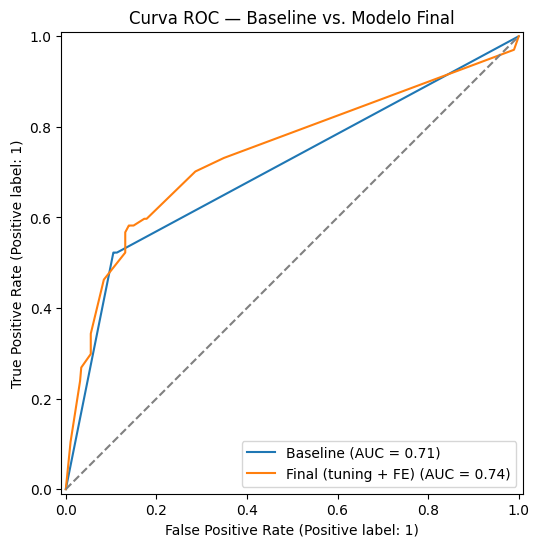

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(yb_test, base_proba, name="Baseline", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba, name="Final (tuning + FE)", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Curva ROC — Baseline vs. Modelo Final")
plt.show()

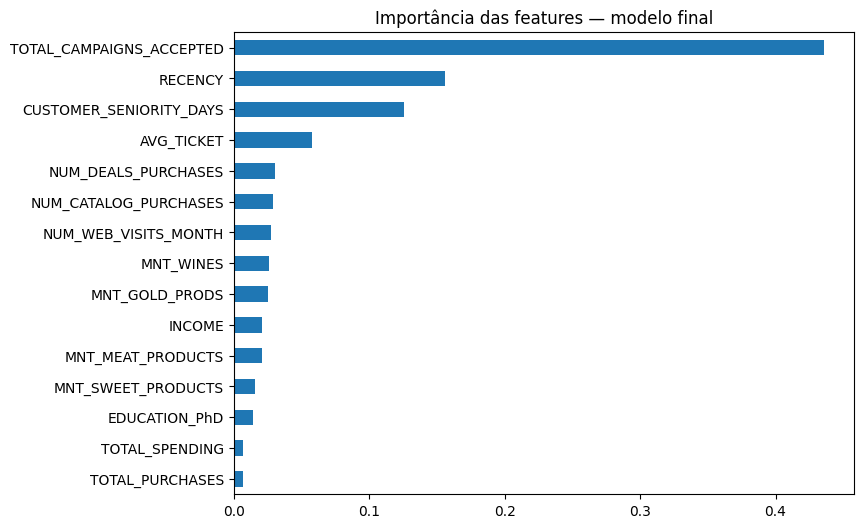

In [15]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Importância das features — modelo final")
plt.gca().invert_yaxis()
plt.show()

## 8. Conclusão

O modelo final, treinado com as features derivadas (`TOTAL_SPENDING`, `TOTAL_PURCHASES`,
`AVG_TICKET`, `TOTAL_CAMPAIGNS_ACCEPTED`, `AGE`, `CUSTOMER_SENIORITY_DAYS`, entre outras) e com
os hiperparâmetros ajustados via `GridSearchCV` (validação cruzada estratificada, apenas nos
dados de treino), supera a Decision Tree de referência em ROC AUC — ver tabela da seção 7 —
sem uso de nenhuma informação do conjunto de teste durante o treinamento ou o tuning
(mediana de `INCOME` e encoding das categóricas foram ajustados apenas no treino, e o HoldOut
foi estratificado e preservado até a avaliação final).